# Loss vs. Combined Loss

Based on the [Loss Comparison Notebook](03_loss.ipynb), **Center Loss** performs best on our dataset with the current training pipeline (**DINOv3** backbone and blurred backgrounds). In this notebook, we compare **Center Loss** with a combined loss consisting of **Center Loss** and **ProxyAnchor Loss**. To further analyze the effect of combining losses, we also include a run using **Center Loss** together with **ArcFaceLoss**. For each loss combination, we train an **embedding projection model** and compare the resulting **identity-balanced mAP** on the validation set.

Training follows the same pipeline used in previous experiments, with the only change being the applied loss function. When combining losses, we control their relative contribution using a `lambda` parameter.

The notebook is structured as follows:

1. **Center Loss** (baseline)
2. **ProxyAnchor Loss + Center Loss**
3. **ArcFaceLoss + Center Loss**

**Wandb runs**:
- Seed 3: https://wandb.ai/karl-schuetz-hasso-plattner-institut/jaguar-reid-karl-matti-schuetz/runs/md9bvsih?nw=nwuserkarlschuetz
- Seed 908: https://wandb.ai/karl-schuetz-hasso-plattner-institut/jaguar-reid-karl-matti-schuetz/runs/zo0usamg?nw=nwuserkarlschuetz
- Seed 45: https://wandb.ai/karl-schuetz-hasso-plattner-institut/jaguar-reid-karl-matti-schuetz/runs/8u5evx5v?nw=nwuserkarlschuetz
- Seed 33: https://wandb.ai/karl-schuetz-hasso-plattner-institut/jaguar-reid-karl-matti-schuetz/runs/insejndd?nw=nwuserkarlschuetz
- Seed 123: https://wandb.ai/karl-schuetz-hasso-plattner-institut/jaguar-reid-karl-matti-schuetz/runs/hxbq8syi?nw=nwuserkarlschuetz

## 1. Setup and Configuration

This section defines the required imports and configuration settings used throughout the notebook. These include library dependencies and any global parameters.

In [1]:
EXPERIMENT_NAME = "04_loss_combined"
RANDOM_SEED = 123 # 3, 908, 45, 33, 123

# -----------------------------
# Environment setup
# -----------------------------
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# -----------------------------
# Standard library imports
# -----------------------------
from dotenv import load_dotenv
from pathlib import Path
import sys
import time

# -----------------------------
# Third-party libraries
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import wandb

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# -----------------------------
# Project path setup
# -----------------------------
PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

# -----------------------------
# Local modules
# -----------------------------
from src.criterions import (
    ArcFaceLoss,
    CenterLoss,
    CombinedLoss,
    ProxyAnchorLoss,
)
from src.datasets import BlurImageDataset, EmbeddingDataset
from src.models import EmbeddingProjection
from src.training import train_loop
from src.utils import (
    create_deterministic_training_dataloader,
    get_device,
    set_seeds,
    extract_embeddings, get_embeddings,
)
from src.visualization import (
    plot_history,
    visualize_embeddings_mds,
    visualize_nearest_neighbors,
)

# -----------------------------
# Reproducibility
# -----------------------------
set_seeds(RANDOM_SEED)
print(f"PyTorch version: {torch.__version__}")

All random seeds set to 123 for reproducibility
PyTorch version: 2.9.1+cu128


Define shared paths for the whole project.

In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

For the configuration, we use the same parameters as in the [Loss Comparison Notebook](03_loss.ipynb), with the addition of a `lambda` parameter to control the contribution of each loss in the combined loss setting.


In [3]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    "proxyanchor_lambda": 0.0005,
    
    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "arcface_lambda": 0.001,

    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Scheduler
    "scheduler_factor": 0.5,
    "scheduler_patience": 5,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  proxyanchor_lambda: 0.0005
  arcface_margin: 0.5
  arcface_scale: 64.0
  arcface_lambda: 0.001
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 200
  patience: 10
  val_split: 0.2
  scheduler_factor: 0.5
  scheduler_patience: 5
  seed: 123


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project=os.getenv("WANDB_PROJECT", "jaguar-reid-karl-matti-schuetz"),
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


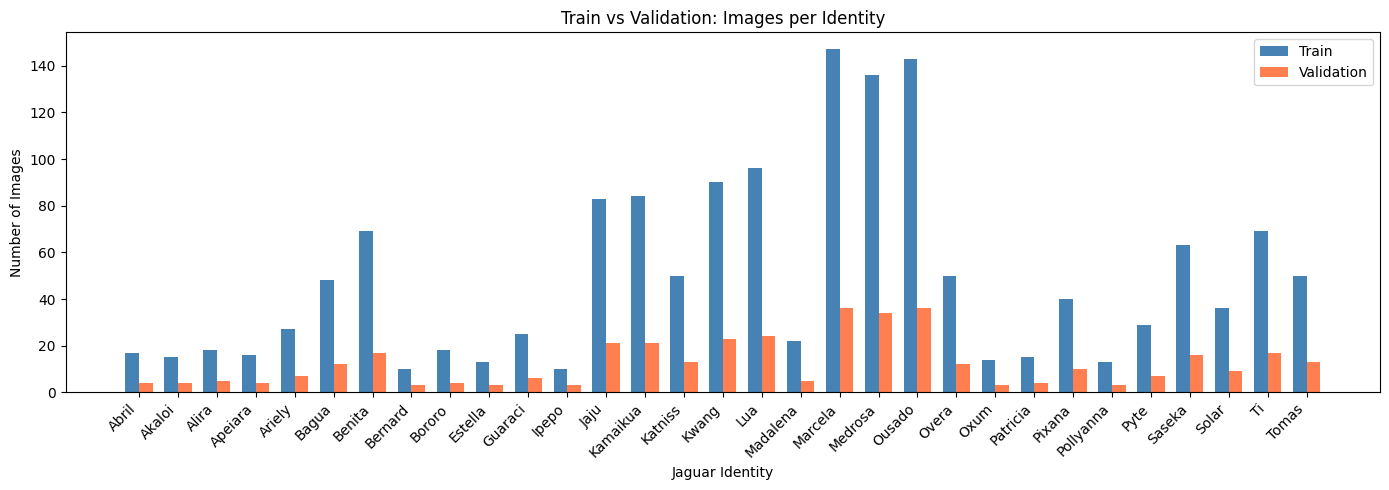


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using CUDA GPU
Using device: cuda
Using num_workers=8 for DataLoader


In [8]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = np.array([DATA_PATH / "train" / fn for fn in filenames])

train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [9]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")
    
wandb.log({
    "dino_num_params": dino_num_params,
    "dino_embedding_dim": dino_dim,
    "dino_input_size": dino_config["input_size"],
    "dino_preprocessing": str(dino_config),
})

Loading Dino model...


Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [10]:
image_dataset = BlurImageDataset(
    image_paths,
    preprocess_fn=dino_preprocess
)
image_loader = DataLoader(
    image_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [11]:
baseline_cache_path = OUTPUT_PATH_SHARED / "dino_blur_embeddings.npz"

baseline_embeddings = get_embeddings(
    model=dino,
    cache_path=baseline_cache_path,
    data_loader=image_loader,
    filenames=filenames,
    device=device
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/shared/dino_blur_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


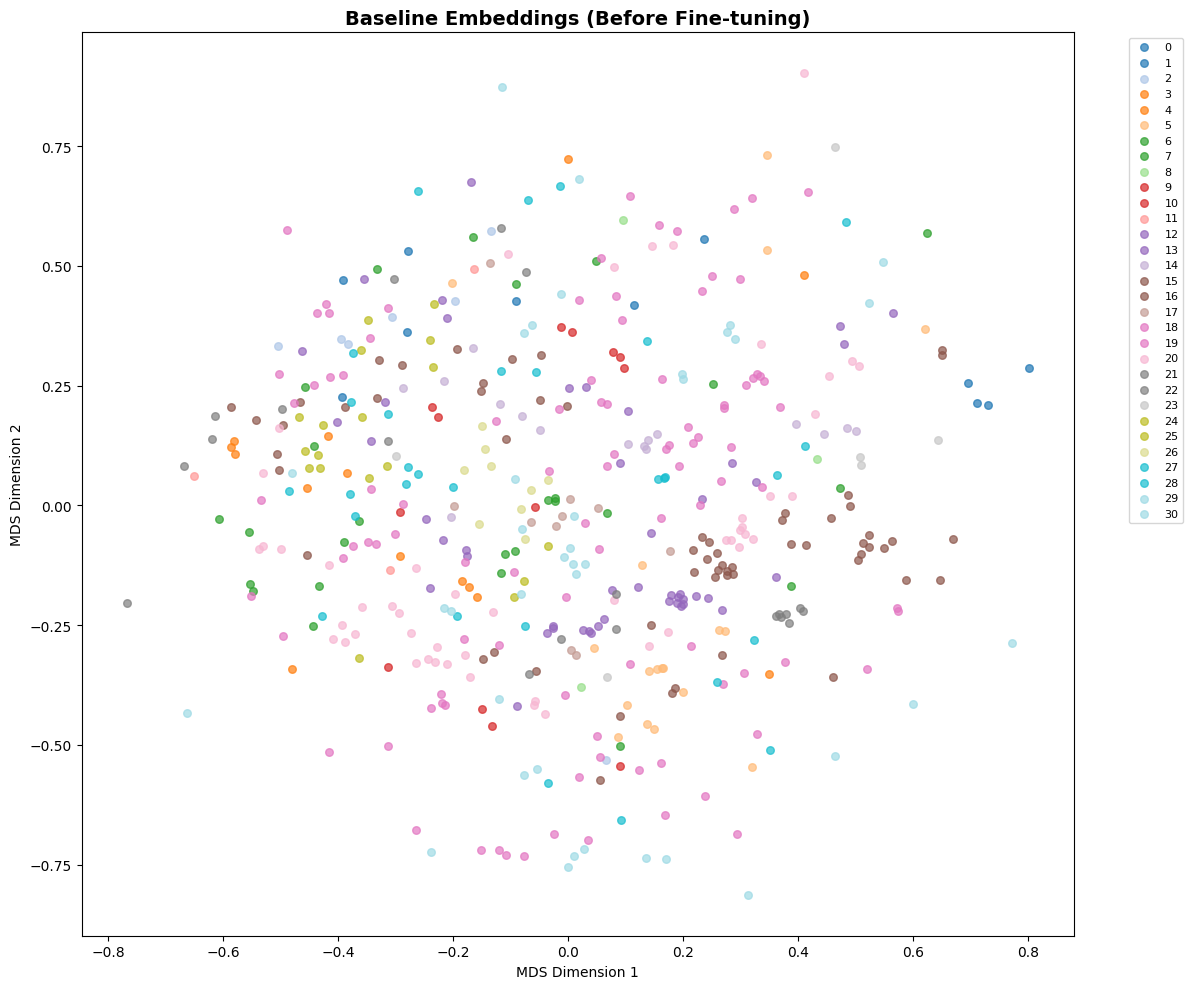

In [12]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [13]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
    
)
baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [14]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

wandb.log({"num_projection_params": sum(p.numel() for p in model.parameters())})

model.print_model_summary()

Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592


During comparison, we initialize each experiment with the same model weights to ensure that differences in performance are not influenced by variations in initialization.

In [15]:
# Export initial model weights for reinitialization
initial_weights_path = CHECKPOINT_PATH / "model_initial_weights.pth"
torch.save(model.state_dict(), initial_weights_path)
print(f"Initial model weights saved to {initial_weights_path}")

Initial model weights saved to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/04_loss_combined/model_initial_weights.pth


In [16]:
table = [
    ["Loss Function", "Best val_mAP", "Best epoch", "Training time"]
]

## Center Loss

**Center Loss** achieved the best performance as a single loss function in the [Loss Comparison Notebook](03_loss.ipynb).


In [17]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion=CenterLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Loss: Center Loss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

print(f"Center Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")

Training components initialized:
  Loss: Center Loss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
Center Loss:
  Embedding dim: 256
  Num classes: 31


In [18]:
# Training loop
set_seeds(config['seed'])
center_checkpoint_path = CHECKPOINT_PATH / "best_center_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="center",
    checkpoint_path=center_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_center": best_map,
    "best_epoch_center": best_epoch,
    "total_epochs_center": len(history['train_loss']),
    "training_time_center": training_time
})

table.append([
    "Center Loss",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 123 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 491.6769
  Val Loss:   356.4689
  Val mAP:    0.3333 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 444.6337
  Val Loss:   329.0396
  Val mAP:    0.3488 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 404.3829
  Val Loss:   297.4904
  Val mAP:    0.3685 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 373.0897
  Val Loss:   279.0531
  Val mAP:    0.3903 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 22.8624
  Val Loss:   23.9318
  Val mAP:    0.8668 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 174/200


  Train Loss: 22.8892
  Val Loss:   23.6871
  Val mAP:    0.8606 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 175/200


  Train Loss: 22.5805
  Val Loss:   23.4488
  Val mAP:    0.8688 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 176/200


  Train Loss: 22.9391
  Val Loss:   23.4756
  Val mAP:    0.8635 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 177/200


  Train Loss: 22.2979
  Val Loss:   23.6792
  Val mAP:    0.8623 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 177 epochs

Training complete!
Best epoch: 167, Val mAP: 0.8707


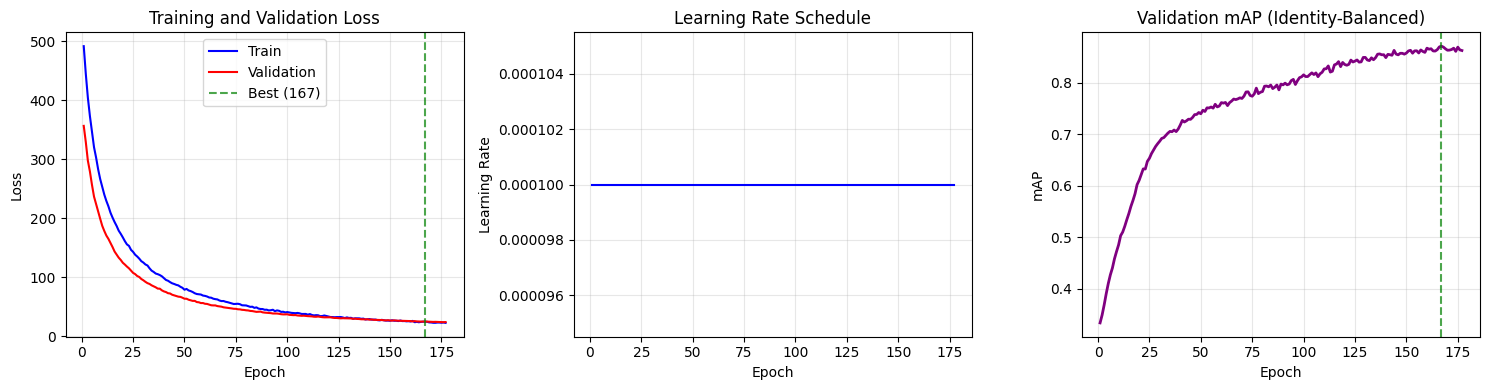

In [19]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_center.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_center": wandb.Image(fig)})

In [20]:
# Load best model
checkpoint = torch.load(center_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 167
  Val Loss: 24.6514
  Val mAP: 0.8707


In [21]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


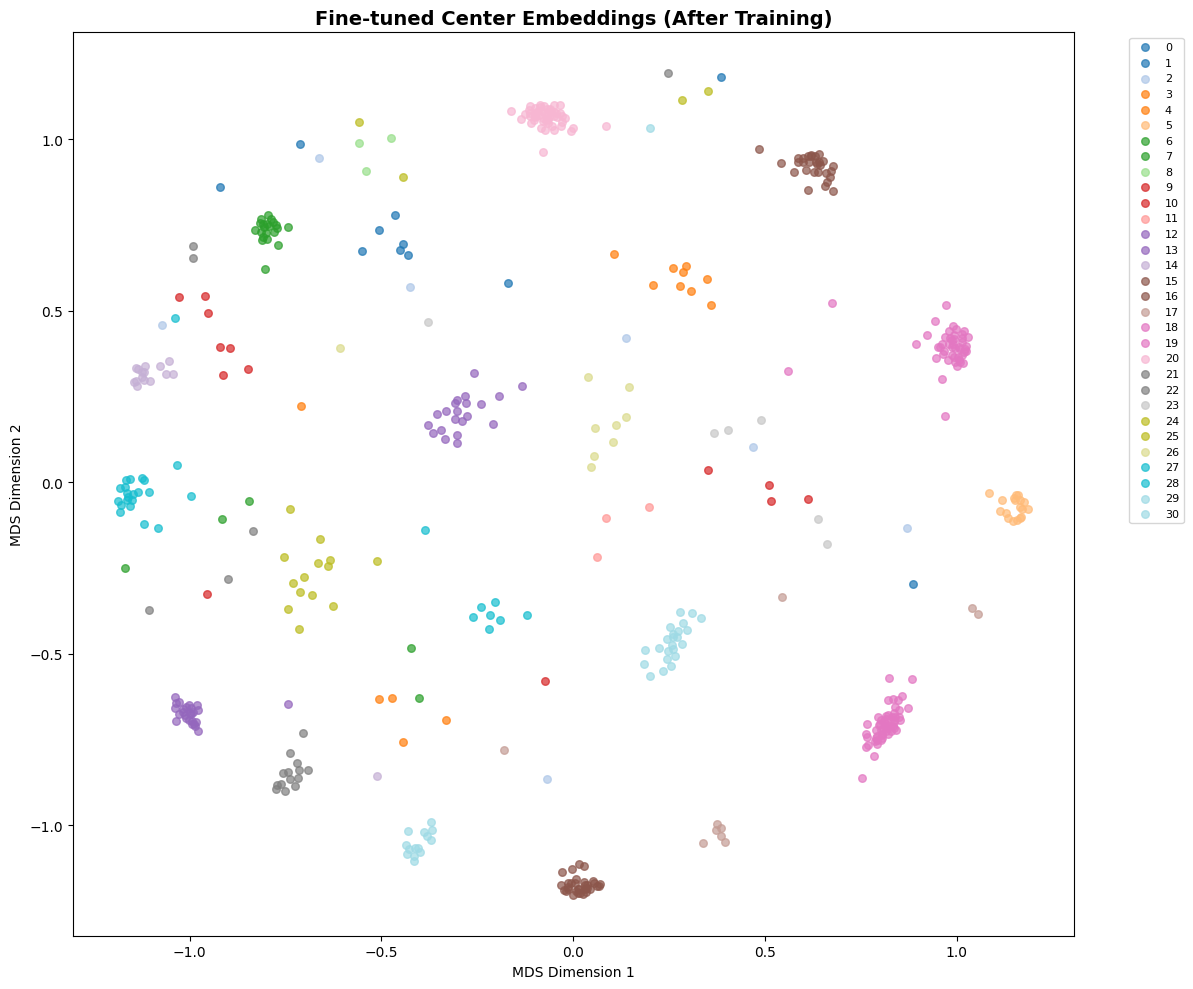

In [22]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Center Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "center_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_center": wandb.Image(fig_finetuned)})

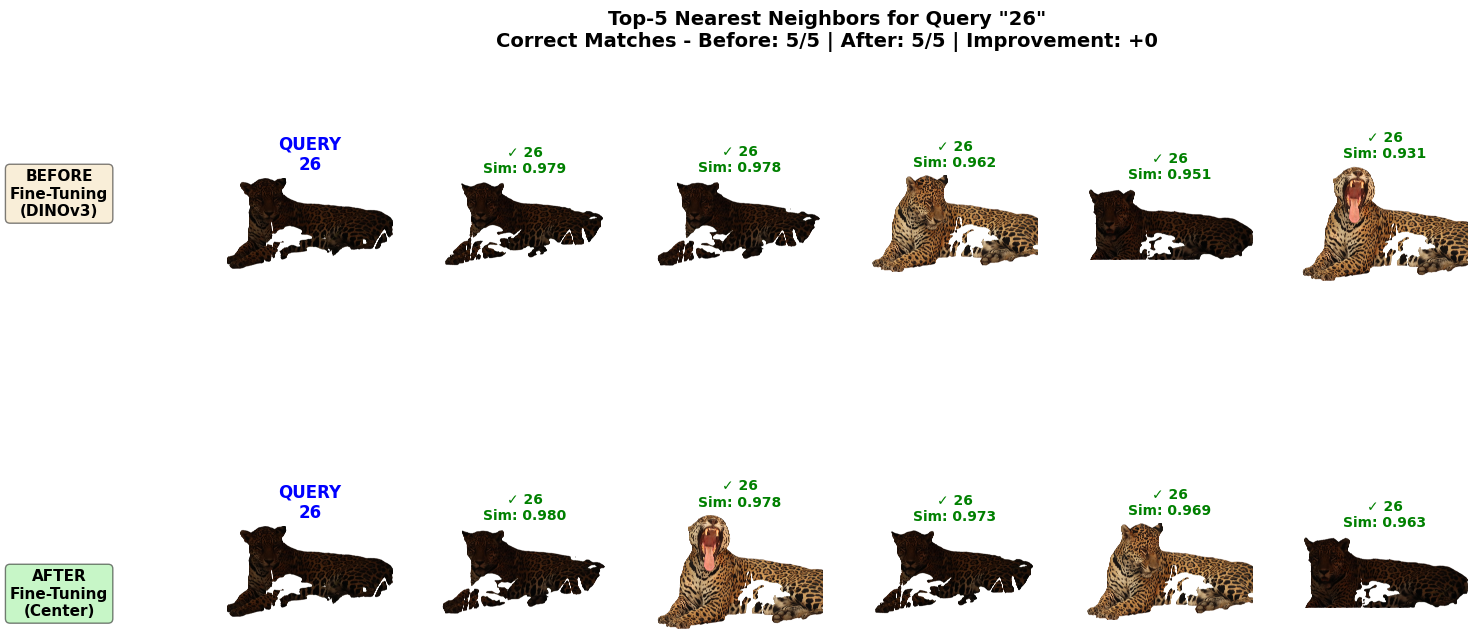

In [23]:
random_idx = np.random.randint(0, len(val_labels))
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
    before_label='BEFORE\nFine-Tuning\n(DINOv3)',
    after_label='AFTER\nFine-Tuning\n(Center)'
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_center.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_center": wandb.Image(fig),
    "nearest_neighbors_stats_center": stats,
})


In [24]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Center Loss + Proxy Anchor Loss

In the [Loss Comparison Notebook](03_loss.ipynb), **Proxy Anchor Loss** showed promising results. Therefore, in this notebook we evaluate whether combining **Center Loss** with **Proxy Anchor Loss** improves the identity-balanced mAP on the validation set.


In [25]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = CombinedLoss(
    first_loss=CenterLoss(
        embedding_dim=config["embedding_dim"],
        num_classes=num_classes
    ),
    second_loss=ProxyAnchorLoss(
        num_classes=num_classes,
        embedding_dim=config["embedding_dim"],
        margin=config["proxyanchor_margin"],
        alpha=config["proxyanchor_alpha"]
    ),
    lambda_center=config["proxyanchor_lambda"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

print(f"Combined Loss:")
print(f"  Components: CenterLoss + ProxyAnchorLoss")
print(f"  Lambda for Proxy Anchor Loss: {config['proxyanchor_lambda']}")

Training components initialized:
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
Combined Loss:
  Components: CenterLoss + ProxyAnchorLoss
  Lambda for Proxy Anchor Loss: 0.0005


In [26]:
# Training loop
set_seeds(config['seed'])
center_proxy_checkpoint_path = CHECKPOINT_PATH / "best_center_proxyanchor.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="combined_proxyanchor_center",
    checkpoint_path=center_proxy_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_center_proxyanchor": best_map,
    "best_epoch_center_proxyanchor": best_epoch,
    "total_epochs_center_proxyanchor": len(history['train_loss']),
    "training_time_center_proxyanchor": training_time
})

table.append([
    "Combined (Center + ProxyAnchor)",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 123 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 495.3565
  Val Loss:   364.0778
  Val mAP:    0.3337 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 445.7855
  Val Loss:   333.0526
  Val mAP:    0.3484 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 404.5481
  Val Loss:   305.2894
  Val mAP:    0.3667 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 20.9813
  Val Loss:   22.1603
  Val mAP:    0.8875 | LR: 1.00e-04
  No improvement. Patience: 2/10

Epoch 197/200


  Train Loss: 21.6523
  Val Loss:   22.0675
  Val mAP:    0.8913 | LR: 1.00e-04
  No improvement. Patience: 3/10

Epoch 198/200


  Train Loss: 21.0110
  Val Loss:   22.0528
  Val mAP:    0.8893 | LR: 1.00e-04
  No improvement. Patience: 4/10

Epoch 199/200


  Train Loss: 21.7382
  Val Loss:   22.3550
  Val mAP:    0.8919 | LR: 1.00e-04
  No improvement. Patience: 5/10

Epoch 200/200


  Train Loss: 19.8539
  Val Loss:   22.1111
  Val mAP:    0.8872 | LR: 1.00e-04
  No improvement. Patience: 6/10

Training complete!
Best epoch: 194, Val mAP: 0.8920


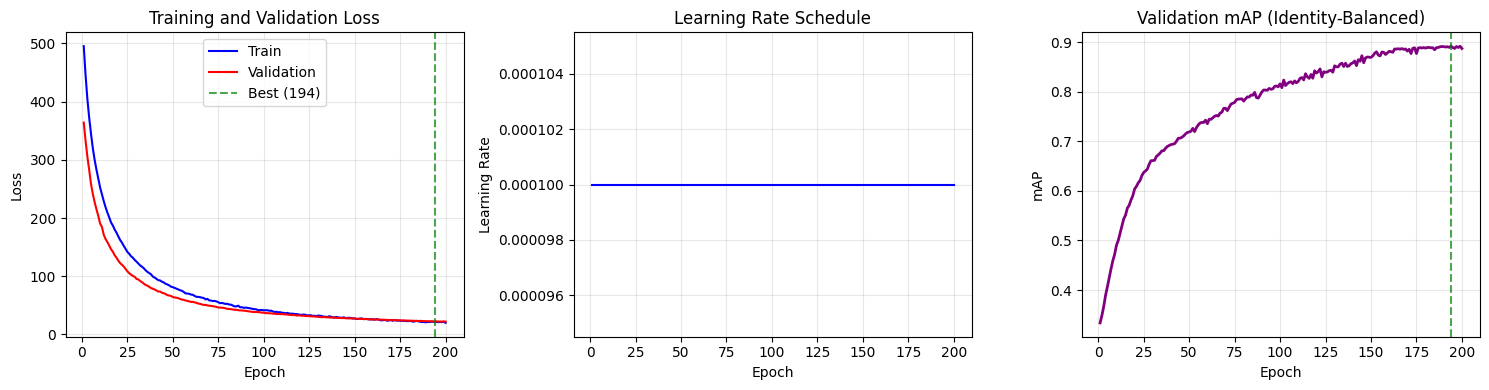

In [27]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_center_proxyanchor.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_center_proxyanchor": wandb.Image(fig)})

In [28]:
# Load best model
checkpoint = torch.load(center_proxy_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 194
  Val Loss: 22.2229
  Val mAP: 0.8920


In [29]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


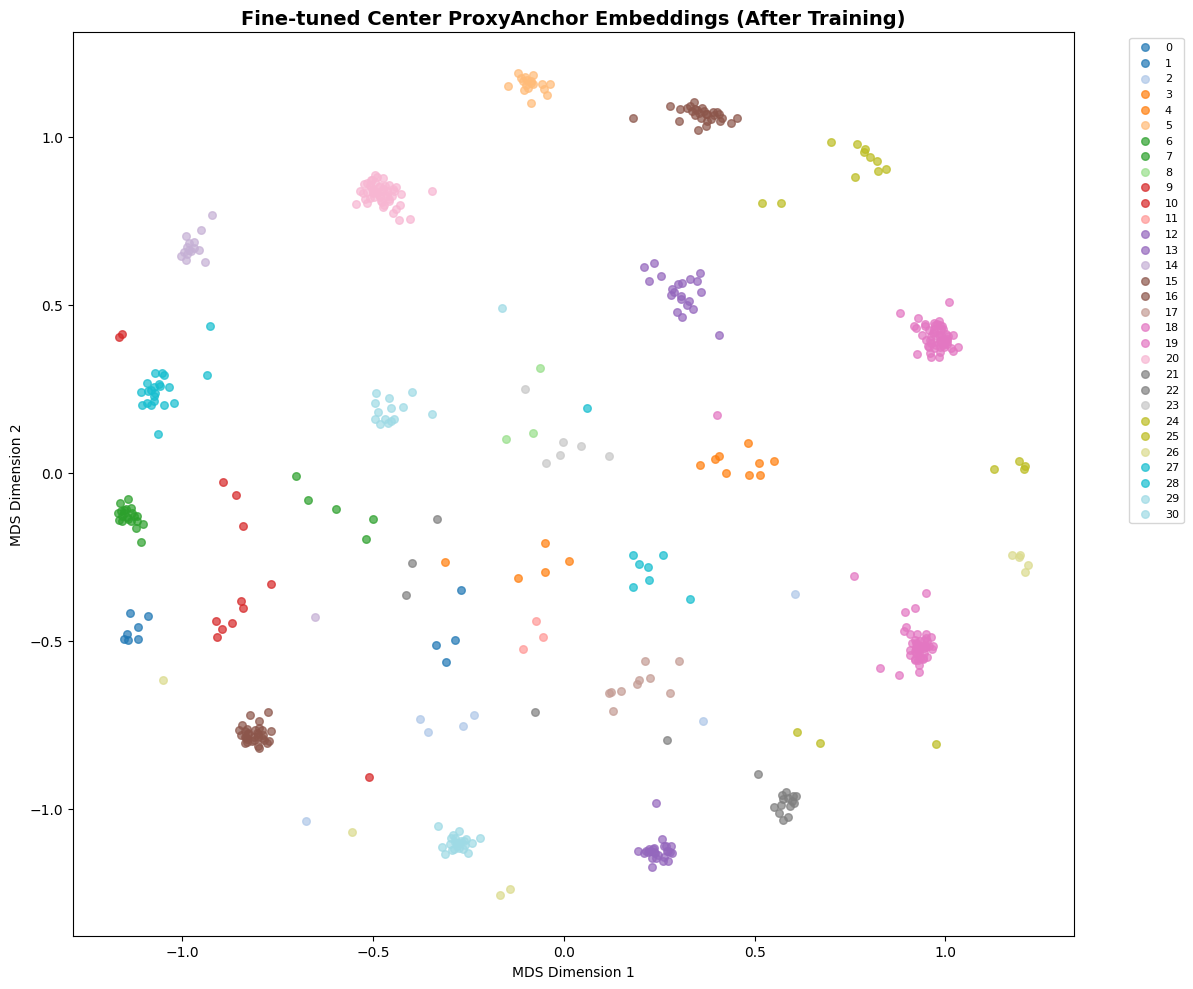

In [30]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Center ProxyAnchor Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "center_proxyanchor_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_center_proxyanchor": wandb.Image(fig_finetuned)})

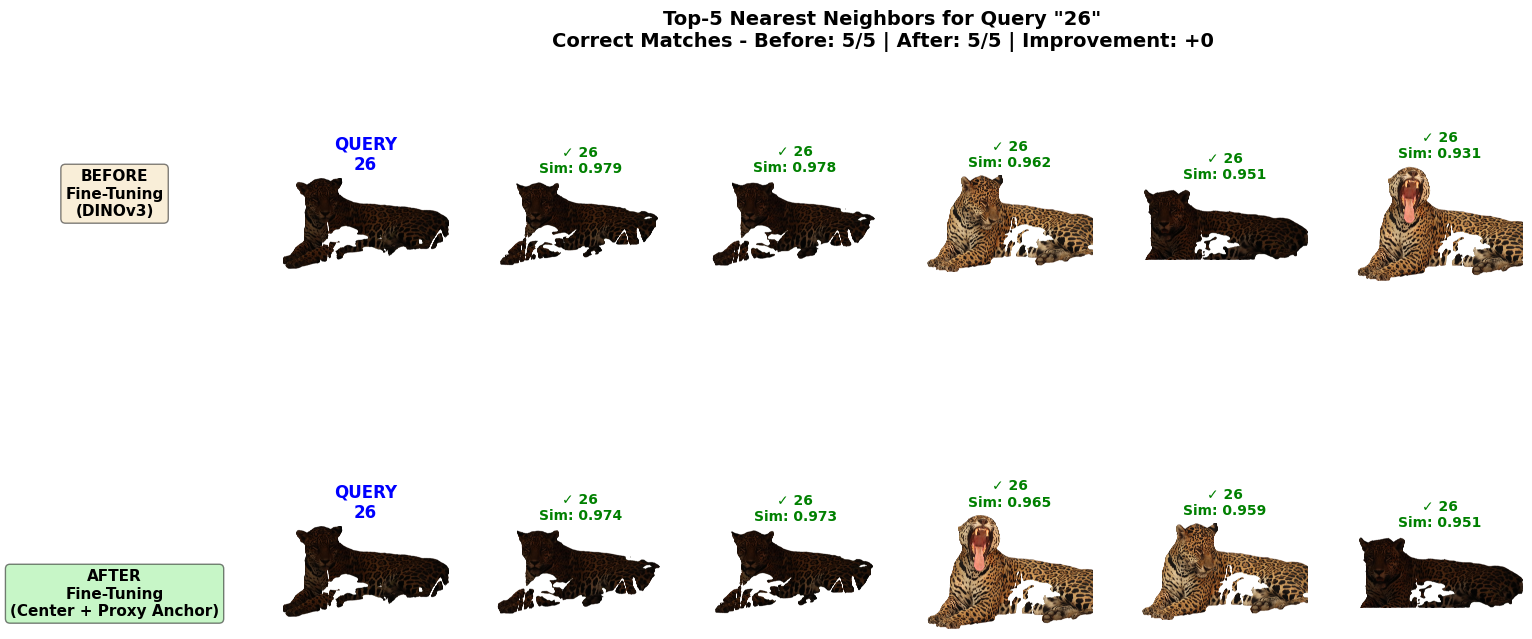

In [31]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
    before_label='BEFORE\nFine-Tuning\n(DINOv3)',
    after_label='AFTER\nFine-Tuning\n(Center + Proxy Anchor)'
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_center_proxyanchor.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_center_proxyanchor": wandb.Image(fig),
    "nearest_neighbors_stats_center_proxyanchor": stats,
})


In [32]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Center Loss + ArcFace Loss

For additional analysis, we also evaluate how combining losses affects **ArcFace Loss**, which served as the baseline loss function prior to the [Loss Comparison Notebook](03_loss.ipynb).


In [33]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = CombinedLoss(
    first_loss=CenterLoss(
        embedding_dim=config["embedding_dim"],
        num_classes=num_classes
    ),
    second_loss=ArcFaceLoss(
        num_classes=num_classes,
        embedding_dim=config["embedding_dim"],
        margin=config["arcface_margin"],
        scale=config["arcface_scale"]
    ),
    lambda_center=config["arcface_lambda"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

print(f"Combined Loss:")
print(f"  Components: CenterLoss + ArcFaceLoss")
print(f"  Lambda for Center Loss: {config['arcface_lambda']}")

Training components initialized:
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
Combined Loss:
  Components: CenterLoss + ArcFaceLoss
  Lambda for Center Loss: 0.001


In [34]:
# Training loop
set_seeds(config['seed'])
center_arcface_checkpoint_path = CHECKPOINT_PATH / "best_center_arcface.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="combined_arcface_center",
    checkpoint_path=center_arcface_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_center_arcface": best_map,
    "best_epoch_center_arcface": best_epoch,
    "total_epochs_center_arcface": len(history['train_loss']),
    "training_time_center_arcface": training_time
})

table.append([
    "Combined (Center + ArcFace)",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 123 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 490.5056
  Val Loss:   361.6712
  Val mAP:    0.3326 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 443.0933
  Val Loss:   326.4531
  Val mAP:    0.3476 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 403.3354
  Val Loss:   304.7115
  Val mAP:    0.3657 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 21.4240
  Val Loss:   23.0208
  Val mAP:    0.8792 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 190/200


  Train Loss: 20.9132
  Val Loss:   22.9876
  Val mAP:    0.8790 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 191/200


  Train Loss: 20.8166
  Val Loss:   23.0949
  Val mAP:    0.8796 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 192/200


  Train Loss: 20.8342
  Val Loss:   22.7363
  Val mAP:    0.8775 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 193/200


  Train Loss: 20.9181
  Val Loss:   22.3912
  Val mAP:    0.8784 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 193 epochs

Training complete!
Best epoch: 183, Val mAP: 0.8804


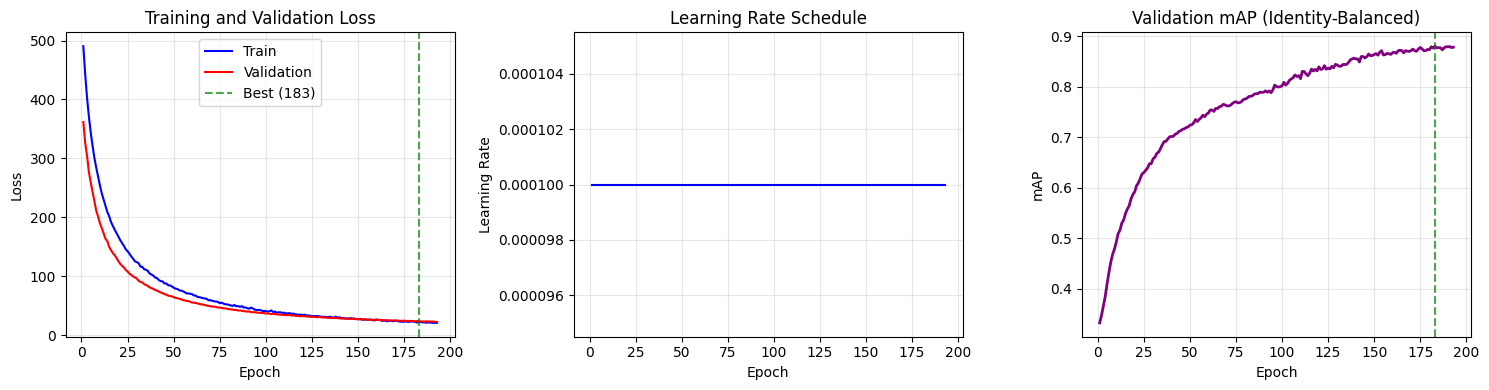

In [35]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_center_arcface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_center_arcface": wandb.Image(fig)})

In [36]:
# Load best model
checkpoint = torch.load(center_arcface_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 183
  Val Loss: 23.5887
  Val mAP: 0.8804


In [37]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


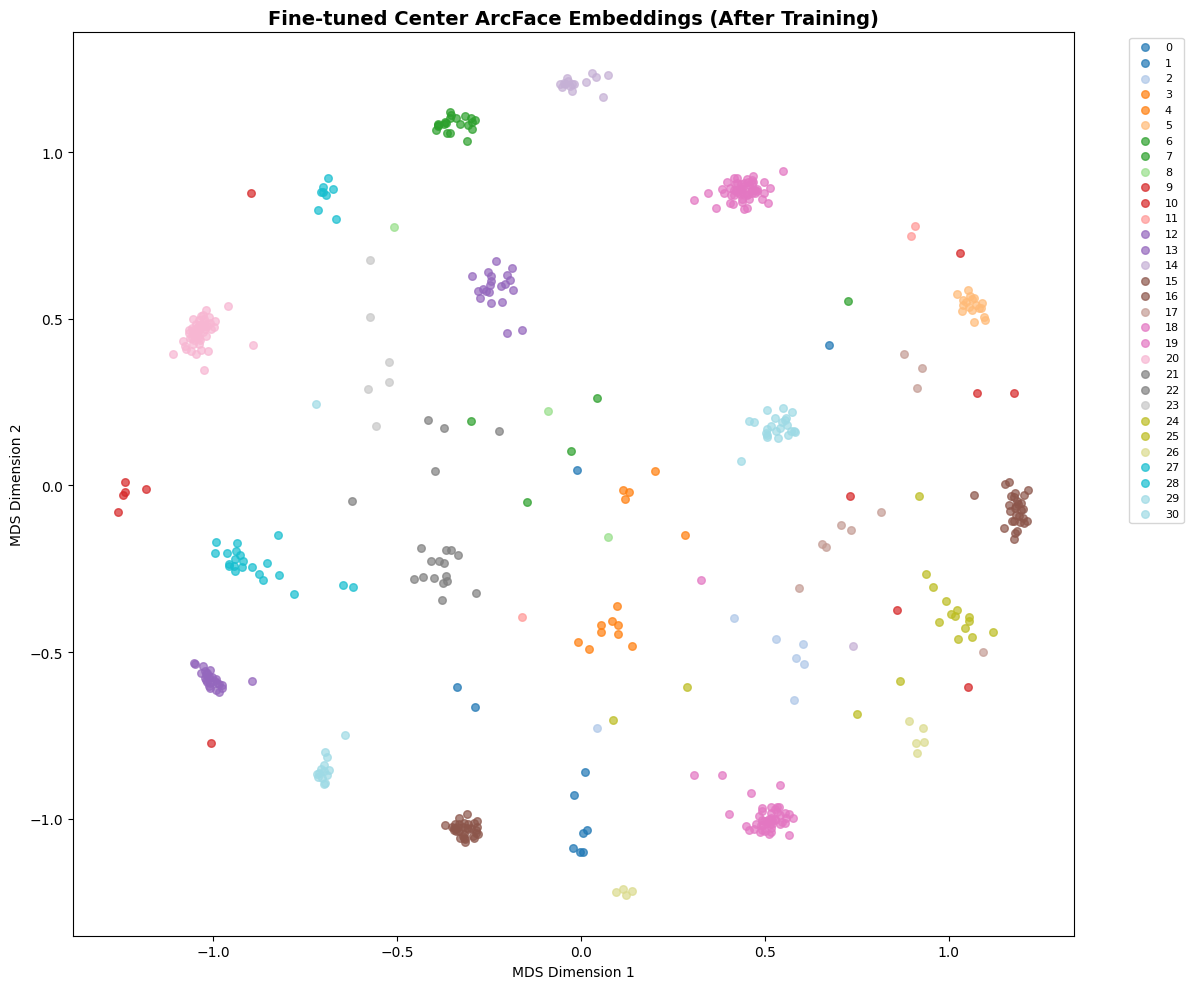

In [38]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Center ArcFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "center_arcface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_center_arcface": wandb.Image(fig_finetuned)})

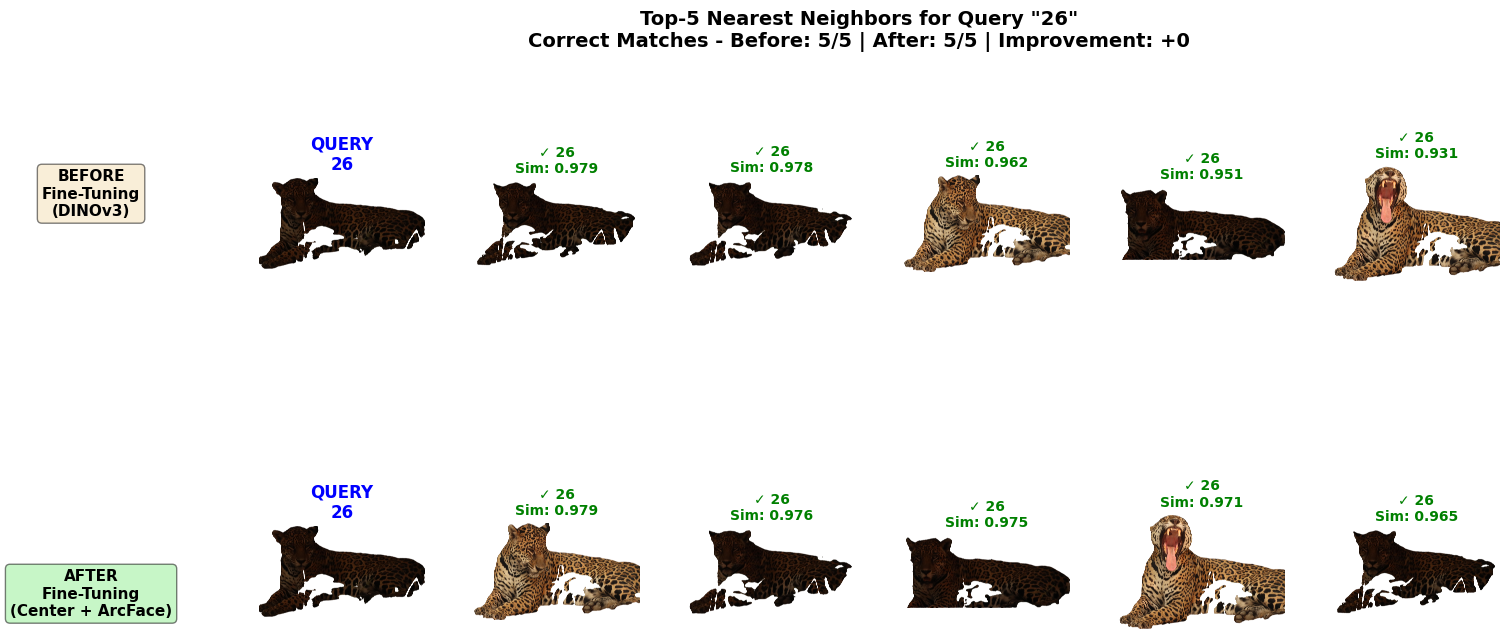

In [39]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
    before_label='BEFORE\nFine-Tuning\n(DINOv3)',
    after_label='AFTER\nFine-Tuning\n(Center + ArcFace)'
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_center_arcface.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_center_arcface": wandb.Image(fig),
    "nearest_neighbors_stats_center_arcface": stats,
})


In [40]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [41]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+-----------------+---------------+-----------------------------------+-------------------------------+
| Loss Function   |   Center Loss |   Combined (Center + ProxyAnchor) |   Combined (Center + ArcFace) |
+=================+===============+===================================+===============================+
| Best val_mAP    |      0.870704 |                          0.891981 |                      0.880382 |
+-----------------+---------------+-----------------------------------+-------------------------------+
| Best epoch      |    167        |                        194        |                    183        |
+-----------------+---------------+-----------------------------------+-------------------------------+
| Training time   |    235.145    |                        303.523    |                    307.59     |
+-----------------+---------------+-----------------------------------+-------------------------------+


In [42]:
# create df from table and log to W&B
df = pd.DataFrame(table[1:], columns=table[0])
print(df)

wandb.log({"experiment_summary": wandb.Table(dataframe=df)})

                     Loss Function  Best val_mAP  Best epoch  Training time
0                      Center Loss      0.870704         167     235.144919
1  Combined (Center + ProxyAnchor)      0.891981         194     303.523207
2      Combined (Center + ArcFace)      0.880382         183     307.589568


Result with random seed 3:
| Loss Function  | Center Loss | Combined (Center + ProxyAnchor) | Combined (Center + ArcFace) |
|----------------|-------------|----------------------------------|------------------------------|
| Best val_mAP   | 0.923984    | 0.926113                         | **0.930783**                     |
| Best epoch     | 153         | 186                              | 172                          |
| Training time  | **206.464** | 289.825                          | 297.105                      |

Result with random seed 908:
| Loss Function  | Center Loss | Combined (Center + ProxyAnchor) | Combined (Center + ArcFace) |
|----------------|-------------|----------------------------------|------------------------------|
| Best val_mAP   | **0.928725**| 0.926888                         | 0.925359                     |
| Best epoch     | 159         | 157                              | 184                          |
| Training time  | **218.455** | 249.796                          | 316.311                      |

Result with random seed 45:
| Loss Function  | Center Loss | Combined (Center + ProxyAnchor) | Combined (Center + ArcFace) |
|----------------|-------------|----------------------------------|------------------------------|
| Best val_mAP   | 0.862973    | **0.867175**                         | 0.843008                     |
| Best epoch     | 185         | 176                              | 144                          |
| Training time  | 252.054     | 278.783                          | **249.897**                      |

Result with random seed 33:
| Loss Function  | Center Loss | Combined (Center + ProxyAnchor) | Combined (Center + ArcFace) |
|----------------|-------------|----------------------------------|------------------------------|
| Best val_mAP   | **0.88077** | 0.877847                         | 0.879712                     |
| Best epoch     | 134         | 136                              | 184                          |
| Training time  | **187.629** | 218.271                          | 327.523                      |

Result with random seed 123:
| Loss Function  | Center Loss | Combined (Center + ProxyAnchor) | Combined (Center + ArcFace) |
|----------------|-------------|----------------------------------|------------------------------|
| Best val_mAP   | 0.870704    | **0.891981**                     | 0.880382                     |
| Best epoch     | 167         | 194                              | 183                          |
| Training time  | **235.145** | 303.523                          | 307.59                       |

| Loss Function                   | Seed 3       | Seed 908     | Seed 45      | Seed 33      | Seed 123     | Mean mAP     | Std (mAP) | Mean Epoch | Mean Time   | Avg Position |
| ------------------------------- | ------------ | ------------ | ------------ | ------------ | ------------ | ------------ | --------- | ---------- | ----------- | ------------ |
| Center Loss                     | 0.923984     | **0.928725** | 0.862973     | **0.880770** | 0.870704     | 0.893431     | 0.030756  | 159.6      | **220**     | 2            |
| Combined (Center + ProxyAnchor) | 0.926113     | 0.926888     | **0.867175** | 0.877847     | **0.891981** | **0.898001** | **0.027465**  | 169.8      | 268         | **1.8**  |
| Combined (Center + ArcFace)     | **0.930783** | 0.925359     | 0.843008     | 0.879712     | 0.880382     | 0.891849     | 0.036411  | 173.4      | 300         | 2.2          |

Across the five seeds, **Combined (Center + Proxy Anchor)** achieves the **highest mean validation mAP (0.898)** and maintains relatively low variance, making it the most consistently strong performer. **Center Loss alone** performs slightly lower (mean mAP 0.893) but has the **shortest training time**, offering an efficient alternative.

For **maximum and consistent re-identification performance**, we want to use **Combined (Center + Proxy Anchor)** in future notebooks.

**Center Loss** reduces intra-class variance, producing compact clusters for each identity, which is especially helpful for rare identities or images with high variation, such as occlusion by vegetation. Adding **Proxy Anchor Loss** introduces inter-class separation through representative proxies, ensuring that these tight clusters are also well spaced in embedding space. This combination yields embeddings that are both compact within classes and well-separated between classes, improving identity-balanced mAP slightly compared to **Center Loss** alone.

## Submission

In [43]:
submission_model = "center_proxy"

submission_dict = {
    "center": center_checkpoint_path,
    "center_proxy": center_proxy_checkpoint_path,
    "center_arcface": center_arcface_checkpoint_path,
}

if submission_model not in submission_dict:
    raise ValueError(f"Invalid submission model: {submission_model}")

checkpoint_path = submission_dict[submission_model]

wandb.log({"submission_type": submission_model})

In [44]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

EmbeddingProjection(
  (network): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [45]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [46]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(
        test_image_paths,
        preprocess_fn=dino_preprocess
    ),
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    model=dino,
    data_loader=test_loader,
    device=device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings: 100%|██████████| 12/12 [01:03<00:00,  5.33s/it]

Test embeddings shape: (371, 768)


In [47]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [48]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities: 100%|██████████| 137270/137270 [00:04<00:00, 32911.02it/s]



Similarity statistics:
  Min: 0.0000
  Max: 0.9969
  Mean: 0.1071
  Std: 0.1897


In [49]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.672495
1       1    0.282204
2       2    0.657905
3       3    0.251397
4       4    0.202267
5       5    0.434712
6       6    0.341607
7       7    0.321951
8       8    0.325652
9       9    0.388148

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [50]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/04_loss_combined/submission.csv
File size: 1914.6 KB


## Artifacts

In [51]:
# Save model as W&B artifact
for key in submission_dict:
    checkpoint_path = submission_dict[key]
    model_artifact = wandb.Artifact(
        name=f"{key}-model",
        type="model",
        description="Fine-tuned MegaDescriptor model for jaguar re-identification with loss: " + key
    )
    model_artifact.add_file(checkpoint_path)
    wandb.log_artifact(model_artifact)

print("Model artifacts saved to W&B")

Model artifacts saved to W&B


In [52]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description=f"Competition submission file for {submission_model} loss"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [53]:
wandb.finish()

best_epoch_center,▁
best_epoch_center_arcface,▁
best_epoch_center_proxyanchor,▁
dino_embedding_dim,▁
dino_num_params,▁
epoch,▃▃▃▄▅▆▇▇▁▁▂▂▂▃▃▄▅▆▇▇▇▇██▂▃▃▃▃▃▄▄▄▅▅▅▆▆▇█
final_val_mAP_center,▁
final_val_mAP_center_arcface,▁
final_val_mAP_center_proxyanchor,▁
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+13,...


Public submission score for seed 123 and center_proxy: 0.806